# Explore Shorter Term Strategies

In both `20260616__umd_variations.ipynb` and `20260620__explore_volume.ipynb`, 
I looked at finding strategies that had a 1+ (hopefully 2+) Sharpe Ratio over
the 5 years from 2021 through 2025.  While I was able to find some strategies
with over a 1 Sharpe Ratio, after some reflection, I thought maybe searching
for a strategy that works over 5+ years with a 2+ Sharpe Ratio is unrealistic.
I feel like, if that existed, the job of Quantitative Analysts/Researchers
wouldn't exist. As an additional point of evidence for this, I have seen
most quant papers sharing quant strategies with a sharpe above 0.5, not above
2.

As a result of this line of thinking, I have come to the conclusion that, 
likely, I should be searching for strategies with decent trends over the long
term (Sharpe above 0.5), then look at how those can be further optimized and tuned
over shorter periods such as taking advantage of micro-level trends that could
exist on the timeframe of months to years, but likely not for 5+ years or a 
longer term than that.  In summary, I am thinking I may have better luck finding
higher Sharpe strategies that return higher for some time, but then may peter out
as the market evolves.  If I were to run these strategies in an automated manner,
I believe it would be best to think of running these as long as they hold a Sharpe
ratio above a certain threshold and auto-shut them off when they dip below that.

## Goal

Explore shorter term strategies in the time frame of `06/01/2024` to `06/01/2026`,
and see if it is possible to obtain higher Sharpe Ratio strategies for a smaller
time horizon.

In [2]:
from binance.client import Client as bnb_client
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wall_street_quants_course_project.models import (
    PriceFrame,
    ReturnFrame,
    PriceNeutralWeightFrame,
    LevelFrame,
)

client = bnb_client(tld='US')

In [3]:
exchange_info = client.get_exchange_info()

usdt_symbols = [
    s['symbol']
    for s in exchange_info['symbols']
    if s['quoteAsset'] == 'USDT' and s['status'] == 'TRADING'
]
print(f"Active USDT pairs: {len(usdt_symbols)}")

Active USDT pairs: 201


In [4]:
univ = usdt_symbols[:]
freq = '1d'
pd_freq = '1d'

start_ts = '2024-06-01'
end_ts = '2026-06-01'
tcost_bps = 20

In [5]:
def get_binance_px(symbol,freq,start_ts=start_ts,end_ts=end_ts):
    data = client.get_historical_klines(symbol,freq,start_ts,end_ts)
    columns = ['open_time','open','high','low','close','volume','close_time','quote_volume',
    'num_trades','taker_base_volume','taker_quote_volume','ignore']

    data = pd.DataFrame(data,columns = columns)
    
    # Convert from POSIX timestamp (number of millisecond since jan 1, 1970)
    data['open_time'] = data['open_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    data['close_time'] = data['close_time'].map(lambda x: datetime.fromtimestamp(x/1000, timezone.utc))
    return data 
    
def get_LevelFrame(data_dict: dict[pd.Series], index_freq: str = pd_freq, remove_tz: bool = True) -> LevelFrame:
    new: pd.DataFrame = pd.DataFrame(data_dict).astype(float)
    new = new.reindex(pd.date_range(new.index[0],new.index[-1],freq=pd_freq))
    if remove_tz:
        new.index = new.index.tz_localize(None) # Drop UTC timestamp, keep only date
    new: LevelFrame = LevelFrame.validate(new)
    return new

In [6]:
px = {}
quote_vol = {}
vol = {}
for x in univ:
    data = get_binance_px(x,freq,start_ts,end_ts)
    px[x] = data.set_index('close_time')['close']
    quote_vol[x] = data.set_index('close_time')['quote_volume']
    vol[x] = data.set_index('close_time')['volume']

In [7]:
px: pd.DataFrame = PriceFrame.validate(get_LevelFrame(px))
quote_vol: LevelFrame = get_LevelFrame(quote_vol)
vol: LevelFrame = get_LevelFrame(vol)

UMD Sharpe Ratio (daily, annualized @ sqrt(365)): 1.134


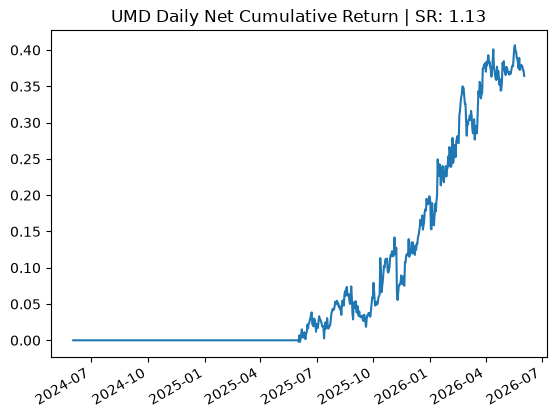

In [28]:
# Daily equivalents of the monthly UMD parameters:
#   monthly shift(1).rolling(11)  →  daily shift(30).rolling(365-30)
# Sharpe annualized with sqrt(365) for daily returns.
TRADING_DAYS_PER_YEAR  = 365
TRADING_DAYS_PER_MONTH = 30
SIGNAL_LOOKBACK_DAYS   = 365-30  # 335 days


def calc_umd_daily(px: PriceFrame, tcost_bps: int = 20) -> tuple:
    ret = ReturnFrame.validate(
        px.copy(deep=True).pct_change(fill_method=None)
    )

    signal = (
        ret
        .shift(periods=TRADING_DAYS_PER_MONTH)
        .rolling(SIGNAL_LOOKBACK_DAYS)
        .mean()
    )
    w = signal.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = PriceNeutralWeightFrame.validate(w)

    port_contrib_ret = w.shift() * ret
    gross_ret        = port_contrib_ret.sum(axis=1)
    to               = (w.fillna(0) - w.shift().fillna(0)).abs().sum(axis=1)
    net_ret          = gross_ret - to * tcost_bps * 1e-4

    return ret, w, port_contrib_ret, gross_ret, net_ret


_, _, _, gross_ret, net_ret = calc_umd_daily(px)

sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)
print(f"UMD Sharpe Ratio (daily, annualized @ sqrt(365)): {sharpe:.3f}")

net_ret.cumsum().plot(
    title=f"UMD Daily Net Cumulative Return | SR: {sharpe:.2f}"
)
plt.show()

### Note on UMD vs DMU for Daily Trading

`calc_umd_daily` uses UMD (momentum) rather than DMU (reversal).
That swap was made because the reversal (DMU) signal did not appear to
work when reformulated for daily trading — specifically, when the
monthly lookback parameters (`shift(1).rolling(11)`) were scaled to
their daily equivalents (`shift(30).rolling(365-30)`).  The momentum
direction (UMD) produced a positive Sharpe of ~1.13 under that
parameterization, whereas the reversal direction did not.

It seems that there is an UMD trend in crypto when rebalancing is
performed at a daily cadence.  It was not seen when rebalancing is
performed at a monthly cadence.

In [29]:
# Copied directly from calc_dmu in the monthly notebooks with no changes
# other than removing the -1 sign flip to make it UMD (momentum) instead
# of DMU (reversal).  Even without any tuning for a shorter time horizon
# or daily data, the Sharpe here appears to exceed the ~1–1.5 upper limit
# seen over the 5-year monthly backtest — consistent with the hypothesis
# in the markdown above that shorter windows may support higher Sharpe
# strategies.
def calc_dmu(px: pd.DataFrame, tcost_bps=20):
    ret = ReturnFrame.validate(px.copy(deep=True).pct_change(fill_method=None))

    w = ret.shift(periods=1).rolling(11).mean()
    w = w.rank(axis=1)
    w = w.subtract(w.mean(axis=1), axis=0)
    w = w.divide(w.abs().sum(axis=1), axis=0)
    w = -1 * w
    w = PriceNeutralWeightFrame.validate(w)

    port_contrib_ret = (w.shift() * ret)

    gross_ret = port_contrib_ret.sum(axis=1)
    to = (
        w.fillna(0) - w.shift().fillna(0)
    ).abs().sum(axis=1)
    net_ret = gross_ret - to * tcost_bps * 1e-4
    return (
        ret,
        w,
        port_contrib_ret,
        gross_ret,
        net_ret,
    )

Sharpe Ratio (daily, annualized @ sqrt(365)): 2.643


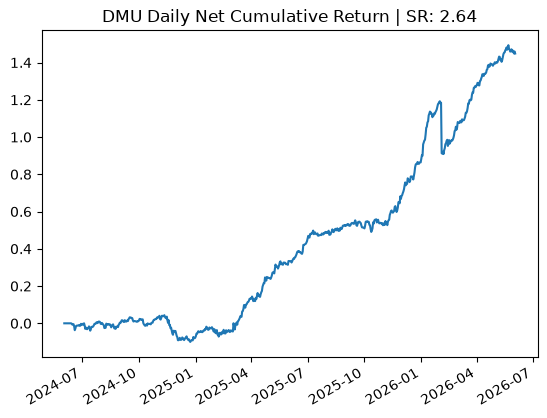

In [30]:
(
    ret,
    w,
    port_contrib_ret,
    gross_ret,
    net_ret,
) = calc_dmu(px)
sharpe = (net_ret.mean() / net_ret.std()) * np.sqrt(TRADING_DAYS_PER_YEAR)
print(f"Sharpe Ratio (daily, annualized @ sqrt(365)): {sharpe:.3f}")

net_ret.cumsum().plot(
    title=f"DMU Daily Net Cumulative Return | SR: {sharpe:.2f}"
)
plt.show()

## Analysis: DMU on Shorter Time Horizon

The copied `calc_dmu` function above — pulled directly from the monthly
notebooks with zero changes — achieves a Sharpe Ratio of **~2.64** on
this 2-year daily window.  This is well above the ~1–1.5 ceiling observed
across the full 5-year monthly backtest, and supports the hypothesis in
the introduction: shorter time horizons can sustain higher Sharpe
strategies, even before any optimization for that regime.

Note on data cadence: in `20260620__explore_volume.ipynb`, `calc_dmu`
was run on **monthly** data (`freq = '1M'`, `pd_freq = 'MS'`) over the
5-year window `2021-01-01` to `2025-12-31`.  There its parameters
`shift(1).rolling(11)` represent a 1-month delay and an 11-month rolling
lookback.

Here, the identical `calc_dmu` code is applied to the **daily** `px` data
built in the cells above (`freq = '1d'` over `2024-06-01` to
`2026-06-01`).  The same `shift(1).rolling(11)` therefore now means a
1-day delay and an 11-day rolling lookback — a much shorter signal window
than in the monthly volume notebook.  The strong Sharpe here comes from
applying that short daily lookback to the 2-year daily window, not from
reusing the monthly parameterization.


## Exploring DMU with Volume Shorter Time Interval + Timeline 

Below, I will try out some different strategies on a 2 years
time horizion and a daily update cadence and see if it's possible
to get a Sharpe Ratio of 2+.

In [31]:
from wall_street_quants_course_project.strats import (
    calc_dmu_parameterized_v1,
    plot_dmu_variation_v1,
)


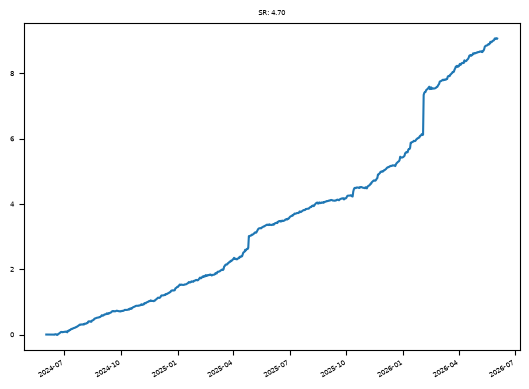

In [10]:
px_thresh = (0.0, 1.0); keep_outside_px=False; px_ma_periods=12; delay_periods=0
vol_thresh = (0.2, 0.5); keep_outside_vol=False; vol_ma_periods=12
reversal=True
plot_dmu_variation_v1(
    px, vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_periods=px_ma_periods, delay_periods=delay_periods, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_periods=vol_ma_periods, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal
)

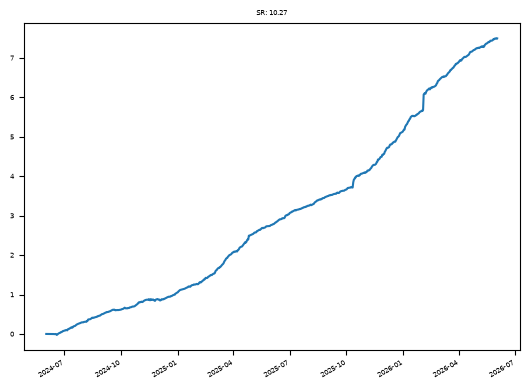

In [33]:
px_thresh = (0.0, 1.0); keep_outside_px=False; px_ma_periods=12; delay_periods=0
vol_thresh = (0.0, 1.0); keep_outside_vol=False; vol_ma_periods=12
reversal=True
plot_dmu_variation_v1(
    px, vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_periods=px_ma_periods, delay_periods=delay_periods, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_periods=vol_ma_periods, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal
)

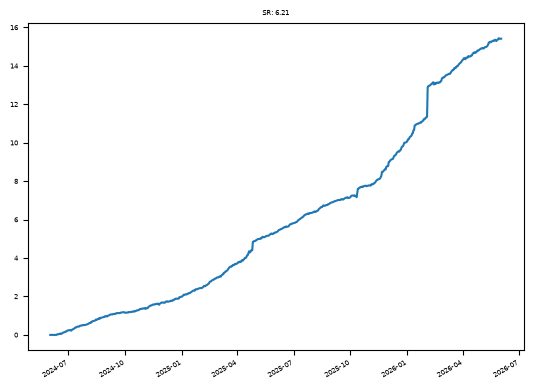

In [34]:
px_thresh = (0.2, 0.8); keep_outside_px=True; px_ma_periods=10; delay_periods=0
vol_thresh = (0.2, 0.8); keep_outside_vol=False; vol_ma_periods=10
reversal=True
plot_dmu_variation_v1(
    px, vol,
    px_lower_pct=px_thresh[0], px_upper_pct=px_thresh[1], px_ma_periods=px_ma_periods, delay_periods=delay_periods, keep_outside_px=keep_outside_px,
    vol_lower_pct=vol_thresh[0], vol_upper_pct=vol_thresh[1], vol_ma_periods=vol_ma_periods, keep_outside_vol=keep_outside_vol,
    tcost_bps=20,reversal=reversal
)

### Exploring DMU with Volume Shorter Time Interval + Timeline Analysis

It is seeming fairly straightfoward to get strategies with a Sharpe Ratio
of 2+ with this setup.  At first, I was thinking that my math must be
incorrect, but I am now wondering if maybe I want to compare these
strategies in different ways such as drawdown and picking a baseline "beta"
to measure against.  I still wonder if my math or some implementation could
be off here as it seems so wildy different than before.  I am curious to 
see if I were to try "paper trading" one of these strategies on a daily
cadence, what it would actually end up looking like and would it come out
as having such great returns and Sharpe Ratio as these above examples?

In [9]:
# With vs. without delay: how much of the Sharpe survives once the
# signal (and volume filter) are not allowed to read the most recent bar?
def sharpe_for_delay(px, vol, delay_periods, **kw):
    _, _, _, _, net_ret = calc_dmu_parameterized_v1(
        px, vol, delay_periods=delay_periods, tcost_bps=20, **kw
    )
    return (net_ret.mean() / net_ret.std()) * np.sqrt(365)


delay_test_configs = {
    "cell14 (vol 0.2-0.5 inside)": dict(
        px_lower_pct=0.0, px_upper_pct=1.0, keep_outside_px=False,
        px_ma_periods=12, vol_lower_pct=0.2, vol_upper_pct=0.5,
        keep_outside_vol=False, vol_ma_periods=12, reversal=True,
    ),
    "cell15 (no vol filter)": dict(
        px_lower_pct=0.0, px_upper_pct=1.0, keep_outside_px=False,
        px_ma_periods=12, vol_lower_pct=0.0, vol_upper_pct=1.0,
        keep_outside_vol=False, vol_ma_periods=12, reversal=True,
    ),
    "cell16 (px tails 0.2-0.8 outside)": dict(
        px_lower_pct=0.2, px_upper_pct=0.8, keep_outside_px=True,
        px_ma_periods=10, vol_lower_pct=0.2, vol_upper_pct=0.8,
        keep_outside_vol=False, vol_ma_periods=10, reversal=True,
    ),
}

delay_test_rows = [
    {
        "config": name,
        "SR delay=0": round(sharpe_for_delay(px, vol, 0, **kw), 2),
        "SR delay=1": round(sharpe_for_delay(px, vol, 1, **kw), 2),
        "SR delay=2": round(sharpe_for_delay(px, vol, 2, **kw), 2),
    }
    for name, kw in delay_test_configs.items()
]
print(pd.DataFrame(delay_test_rows).to_string(index=False))

                           config  SR delay=0  SR delay=1  SR delay=2
      cell14 (vol 0.2-0.5 inside)        4.70        0.41       -0.25
           cell15 (no vol filter)       10.27        2.64        0.81
cell16 (px tails 0.2-0.8 outside)        6.21        2.80        1.67


### With vs. Without Delay: Interpreting the Result

`delay_periods` now gates **both** the price signal and the volume
filter, so neither is allowed to read data more recent than
`delay_periods` bars ago.  The total lookback is held fixed
(`px_ma_periods` / `vol_ma_periods`) — increasing the delay only pushes
the window further into the past.

| config | SR delay=0 | SR delay=1 | SR delay=2 |
|---|---|---|---|
| cell14 (vol 0.2-0.5 inside) | 4.70 | 0.41 | -0.25 |
| cell15 (no vol filter) | 10.27 | 2.64 | 0.81 |
| cell16 (px tails 0.2-0.8 outside) | 6.21 | 2.80 | 1.67 |

The collapse from `delay=0` to `delay=1` is the answer to the
"am I seeing the future?" question.  At `delay=0` the signal's most
recent input is the return of the bar that *just closed*, and the book
is then assumed to capture the very next bar — i.e. it leans on trading
at the same close it just observed.  That same-bar timing is not
realistically executable, and it is responsible for the bulk of the
eye-popping Sharpe (e.g. 10.27 → 2.64 with no volume filter).

At `delay=1` there is a full bar between the last observed data and the
return earned, which is executable.  The Sharpe there is still high
(~2.6–2.8 for the better configs) and then decays further at `delay=2`,
which is the expected signature of a genuine but *short-lived*
reversal/momentum edge — consistent with the notebook's thesis that
shorter horizons can carry higher Sharpe.  So: not pure lookahead, but a
meaningful slice of the headline number was unrealistic same-bar timing.
The realistic, `delay>=1` numbers are the ones to trust.
